# Inside the night: 1.3 million sensor readings

Every other notebook here uses one summary row per night. This one goes a layer
down, into the series Oura records *during* the night and exposes through the
API:

| Signal | Resolution | Samples |
|---|---|---|
| Heart rate | every 5 minutes | 130,305 |
| HRV | every 5 minutes | 130,305 |
| Sleep stage (hypnogram) | every 30 seconds | 1,296,727 |
| Movement | every 30 seconds | 1,296,727 |

**What this is not.** Oura does not expose the raw PPG waveform or the
accelerometer axes through the public API, so none of this is truly raw sensor
data. It is their processed per-epoch output. Worth stating plainly, because the
difference matters and the summaries alone would let you imply otherwise.

**What it is good for.** The summaries say *how much* REM I got. The hypnogram
says *when*. Those answer different questions, and one of them settles a claim
notebook 03 could only approach sideways.

It also answers something that notebook 04 got wrong.

In [1]:
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine
from dotenv import load_dotenv

sys.path.insert(0, "..")
load_dotenv("../.env")

SURFACE, INK, INK2, BLUE = "#fcfcfb", "#0b0b0b", "#52514e", "#2a78d6"
RED, GREEN, SAND = "#c25a4a", "#5f8a4f", "#d8b26a"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "text.color": INK, "axes.labelcolor": INK2,
    "xtick.color": INK2, "ytick.color": INK2,
    "axes.grid": True, "grid.color": "#e6e5e1", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "font.size": 10,
})

engine = create_engine(os.environ["DATABASE_URL"])

arch = pd.read_sql("""
    SELECT *, sleep_algorithm_version AS algo
    FROM marts.mart_sleep_architecture
    ORDER BY day
""", engine, parse_dates=["day"])

print(f"{len(arch)} nights of architecture")
print(f"{arch.epochs_in_sleep_period.sum():,} sleep epochs analysed")

1266 nights of architecture
1,236,807 sleep epochs analysed


## 1. One night, drawn

Before any aggregate, it is worth seeing what the data actually is. This is a
single night: the hypnogram underneath, heart rate and HRV on top.

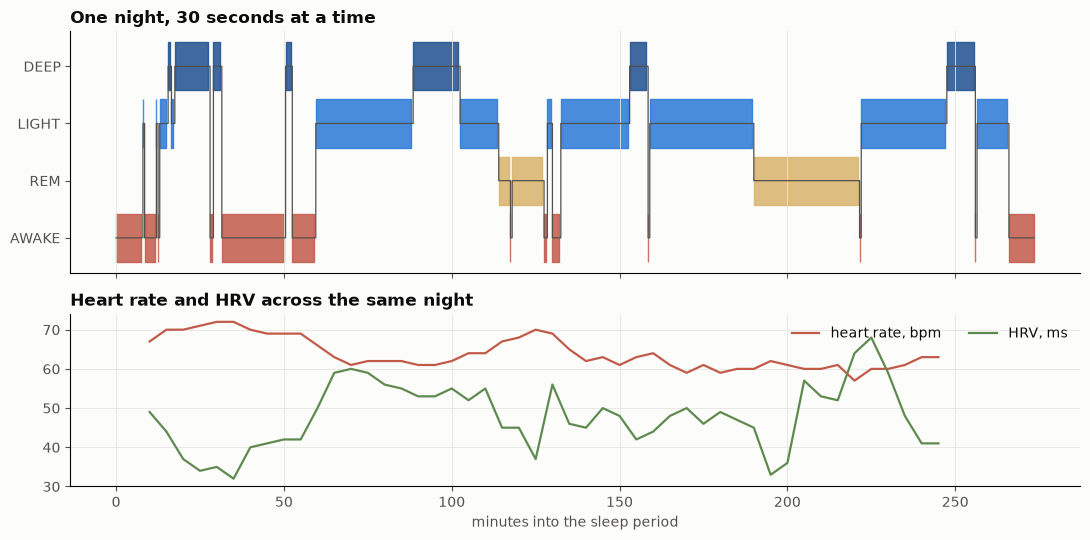

548 epochs, 55 vitals samples for this night


In [2]:
night = pd.read_sql("""
    SELECT p.minutes_into_sleep, p.sleep_phase, p.phase_code, p.movement_code
    FROM staging.stg_sleep_phases p
    JOIN (SELECT doc_id FROM marts.mart_sleep_architecture
          WHERE day = '2026-07-20') s USING (doc_id)
    ORDER BY p.epoch_index
""", engine)

vitals = pd.read_sql("""
    SELECT h.minutes_into_sleep, h.heart_rate, h.hrv
    FROM staging.stg_sleep_hr_hrv h
    JOIN (SELECT doc_id FROM marts.mart_sleep_architecture
          WHERE day = '2026-07-20') s USING (doc_id)
    ORDER BY h.sample_index
""", engine)

fig, axes = plt.subplots(2, 1, figsize=(11, 5.5), sharex=True,
                         height_ratios=[1.4, 1])

# Hypnogram: deep at the bottom, awake at the top, the convention in sleep medicine
order = {"deep": 0, "light": 1, "rem": 2, "awake": 3}
colours = {"deep": "#1f4f8f", "light": BLUE, "rem": SAND, "awake": RED}
ax = axes[0]
y = night.sleep_phase.map(order)
ax.step(night.minutes_into_sleep, y, where="post", color=INK2, linewidth=0.9)
for phase, lvl in order.items():
    m = night.sleep_phase == phase
    ax.fill_between(night.minutes_into_sleep, lvl - 0.42, lvl + 0.42,
                    where=m, step="post", color=colours[phase], alpha=0.85)
ax.set_yticks(list(order.values()))
ax.set_yticklabels([p.upper() for p in order])
ax.invert_yaxis()
ax.set_title("One night, 30 seconds at a time", loc="left",
             fontweight="bold", color=INK)
ax.grid(axis="y", visible=False)

ax = axes[1]
ax.plot(vitals.minutes_into_sleep, vitals.heart_rate, color=RED,
        linewidth=1.6, label="heart rate, bpm")
ax.plot(vitals.minutes_into_sleep, vitals.hrv, color=GREEN,
        linewidth=1.6, label="HRV, ms")
ax.set_xlabel("minutes into the sleep period")
ax.legend(frameon=False, ncol=2)
ax.set_title("Heart rate and HRV across the same night",
             loc="left", fontweight="bold", color=INK)

plt.tight_layout(); plt.show()

print(f"{len(night)} epochs, {len(vitals)} vitals samples for this night")

The shape is the textbook one: deep sleep front-loaded, REM arriving later and in
longer blocks, heart rate sinking while HRV climbs. Nothing surprising, which is
the point. If this did not look like a hypnogram, the parsing would be wrong.

## 2. Settling a claim from notebook 03

Notebook 03 concluded that REM concentrates at the morning end of the night. The
evidence was indirect: REM *share* correlated with wake-up time at r = 0.19, so
later wake-ups implied more REM. That is an inference about within-night
structure made entirely from between-night summaries.

The hypnogram measures it directly. Split every night into thirds of its own
sleep period, so a five-hour night and a nine-hour night stay comparable, and
count what is in each third.

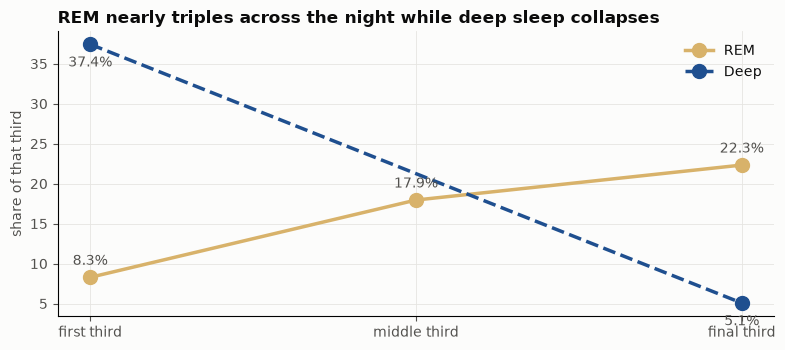

REM:  8.28% -> 17.95% -> 22.32%  (2.7x)
Deep: 37.43% -> 5.07%  (7.4x lower)

Standard sleep-medicine metrics, for orientation:
  sleep onset latency                 13.5 min  10-20 typical
  REM latency                        100.6 min  70-120 typical
  wake after sleep onset              55.5 min  under 30 is good
  awakenings                          23.5      Oura counts brief arousals
  minutes to lowest heart rate       329.0 min  
  HRV change, first hour to last      13.5 ms   positive = recovering


In [3]:
thirds = pd.DataFrame({
    "REM":  [arch.rem_pct_third_1.mean(), arch.rem_pct_third_2.mean(), arch.rem_pct_third_3.mean()],
    "Deep": [arch.deep_pct_third_1.mean(), None, arch.deep_pct_third_3.mean()],
}, index=["first third", "middle third", "final third"])

fig, ax = plt.subplots(figsize=(8, 3.6))
x = np.arange(3)
ax.plot(x, thirds.REM, "o-", color=SAND, linewidth=2.5, markersize=10, label="REM")
ax.plot([0, 2], [thirds.Deep.iloc[0], thirds.Deep.iloc[2]], "o--",
        color="#1f4f8f", linewidth=2.5, markersize=10, label="Deep")
for i, v in enumerate(thirds.REM):
    ax.annotate(f"{v:.1f}%", (i, v), ha="center", xytext=(0, 9),
                textcoords="offset points", color=INK2)
for i, v in [(0, thirds.Deep.iloc[0]), (2, thirds.Deep.iloc[2])]:
    ax.annotate(f"{v:.1f}%", (i, v), ha="center", xytext=(0, -16),
                textcoords="offset points", color=INK2)
ax.set_xticks(x); ax.set_xticklabels(thirds.index)
ax.set_ylabel("share of that third")
ax.set_title("REM nearly triples across the night while deep sleep collapses",
             loc="left", fontweight="bold", color=INK)
ax.legend(frameon=False)
plt.tight_layout(); plt.show()

print(f"REM:  {arch.rem_pct_third_1.mean():.2f}% -> {arch.rem_pct_third_2.mean():.2f}% "
      f"-> {arch.rem_pct_third_3.mean():.2f}%  "
      f"({arch.rem_pct_third_3.mean()/arch.rem_pct_third_1.mean():.1f}x)")
print(f"Deep: {arch.deep_pct_third_1.mean():.2f}% -> {arch.deep_pct_third_3.mean():.2f}%  "
      f"({arch.deep_pct_third_1.mean()/arch.deep_pct_third_3.mean():.1f}x lower)")
print()
print("Standard sleep-medicine metrics, for orientation:")
for label, col, unit, normal in [
    ("sleep onset latency", "sleep_onset_latency_min", "min", "10-20 typical"),
    ("REM latency", "rem_latency_min", "min", "70-120 typical"),
    ("wake after sleep onset", "waso_min", "min", "under 30 is good"),
    ("awakenings", "awakenings", "", "Oura counts brief arousals"),
    ("minutes to lowest heart rate", "minutes_to_hr_nadir", "min", ""),
    ("HRV change, first hour to last", "hrv_overnight_change", "ms", "positive = recovering"),
]:
    print(f"  {label:32s} {arch[col].mean():7.1f} {unit:4s} {normal}")

**Verdict: confirmed, and much more strongly than the correlation suggested.**
REM runs 8.3% of the first third and 22.3% of the final third, nearly tripling,
while deep sleep falls from 37.4% to 5.1%. The indirect estimate was right about
the direction and had no way to show the size.

This is what the extra resolution buys. The summaries could support "later
wake-ups come with more REM"; the hypnogram supports "the last third of the
night is where REM lives, so an hour cut from the morning end costs
disproportionately more REM than an hour cut from the start". That is a
different, more useful claim, and it strengthens the practical conclusion in
notebook 03: the missing eighth hour is expensive precisely because of where it
sits.

The other metrics land in normal ranges, which is a check on the parsing rather
than a finding. One exception: my lowest heart rate arrives about 5.5 hours in,
where the textbook pattern is earlier. Worth a look another time.

## 3. Where notebook 04 was wrong

Notebooks 03 and 04 withdrew a claimed multi-year decline in REM share, on the
grounds that a block bootstrap put the trend's confidence interval across zero.
That withdrawal stands. But the *explanation* offered was that a step change
sat "around November 2023, near a staging algorithm update", inferred from where
the drop appeared on a chart.

The raw payload has carried a field called `sleep_algorithm_version` since the
first ingest. Nobody parsed it. It records exactly which version scored each
night, and it disagrees with that account.

In [4]:
by_algo = arch.groupby("algo", observed=True).agg(
    nights=("day", "size"), first=("day", "min"), last=("day", "max"),
    deep=("deep_pct", "mean"), light=("light_pct", "mean"),
    rem=("rem_pct", "mean"), awakenings=("awakenings", "mean"),
).sort_values("first")
by_algo[["deep", "light", "rem", "awakenings"]] = \
    by_algo[["deep", "light", "rem", "awakenings"]].round(2)
print(by_algo.to_string())

BOUNDARY = pd.Timestamp("2023-06-21")
print()
print(f"The version boundary is {BOUNDARY.date()}, not November 2023.")

# Is the change abrupt, or a drift that happens to straddle the boundary?
v1_end = arch[arch.algo == "v1"].nlargest(30, "day")
v2_start = arch[arch.algo == "v2"].nsmallest(30, "day")
v2_next = arch[arch.algo == "v2"].nsmallest(90, "day").tail(60)
print()
print("            last 30 nights on v1 | first 30 on v2 | next 60 on v2")
print(f"  deep %          {v1_end.deep_pct.mean():13.2f} | {v2_start.deep_pct.mean():13.2f} | "
      f"{v2_next.deep_pct.mean():12.2f}")
print(f"  light %         {v1_end.light_pct.mean():13.2f} | {v2_start.light_pct.mean():13.2f} | "
      f"{v2_next.light_pct.mean():12.2f}")

# Sharpest changepoint search: how special is that date?
d = arch.dropna(subset=["deep_pct"]).reset_index(drop=True)
b = d.index[d.day >= BOUNDARY][0]
observed = abs(d.deep_pct[:b].mean() - d.deep_pct[b:].mean())
candidates = range(60, len(d) - 60)
gaps = np.array([abs(d.deep_pct[:i].mean() - d.deep_pct[i:].mean()) for i in candidates])
rank = int((gaps > observed).sum()) + 1
best_day = d.day[list(candidates)[int(gaps.argmax())]].date()
print()
print(f"  deep% gap at the version boundary : {observed:.2f} points")
print(f"  best gap at any other split point : {gaps.max():.2f} points (at {best_day})")
print(f"  the boundary ranks {rank} of {len(gaps)} possible split points")

                nights      first       last   deep  light    rem  awakenings
algo                                                                         
pre-versioning     242 2022-08-23 2023-04-21  25.98  43.68  18.62       18.92
v1                  43 2023-05-06 2023-06-20  28.46  41.16  16.44       21.14
v2                 981 2023-06-21 2026-07-25  18.00  56.34  15.57       24.77

The version boundary is 2023-06-21, not November 2023.

            last 30 nights on v1 | first 30 on v2 | next 60 on v2
  deep %                  28.31 |         17.90 |        17.85
  light %                 40.98 |         55.58 |        53.76

  deep% gap at the version boundary : 8.36 points
  best gap at any other split point : 8.39 points (at 2023-06-12)
  the boundary ranks 6 of 1146 possible split points


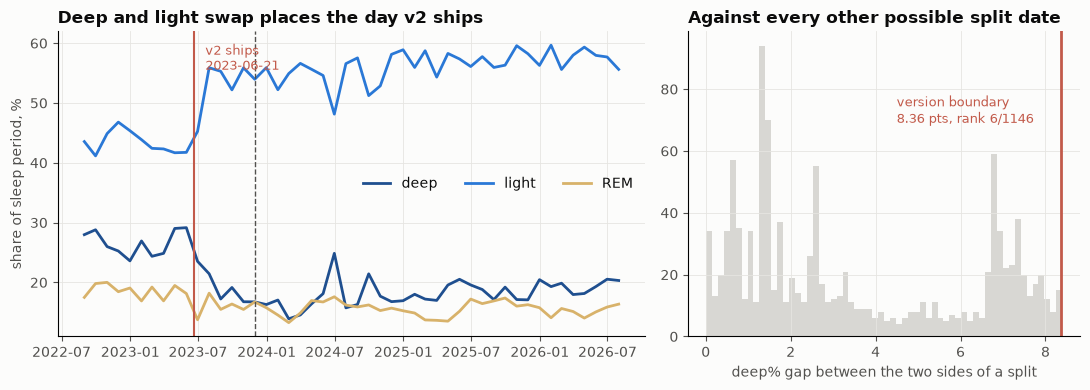

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), width_ratios=[1.5, 1])

ax = axes[0]
monthly = arch.set_index("day")[["deep_pct", "light_pct", "rem_pct"]].resample("ME").mean()
for col, colour, label in [("deep_pct", "#1f4f8f", "deep"),
                           ("light_pct", BLUE, "light"),
                           ("rem_pct", SAND, "REM")]:
    ax.plot(monthly.index, monthly[col], color=colour, linewidth=2, label=label)
ax.axvline(BOUNDARY, color=RED, linewidth=1.5)
ax.annotate("v2 ships\n2023-06-21", (BOUNDARY, ax.get_ylim()[1] * 0.97),
            xytext=(8, 0), textcoords="offset points", color=RED, fontsize=9, va="top")
ax.axvline(pd.Timestamp("2023-11-30"), color=INK2, linewidth=1, linestyle="--")
ax.annotate("where notebook 04\nsaid the step was", (pd.Timestamp("2023-11-30"), 8),
            xytext=(8, 0), textcoords="offset points", color=INK2, fontsize=8)
ax.set_ylabel("share of sleep period, %")
ax.set_title("Deep and light swap places the day v2 ships", loc="left",
             fontweight="bold", color=INK)
ax.legend(frameon=False, ncol=3)

ax = axes[1]
ax.hist(gaps, bins=60, color="#d8d7d3")
ax.axvline(observed, color=RED, linewidth=2)
ax.annotate(f"version boundary\n{observed:.2f} pts, rank {rank}/{len(gaps)}",
            (observed, ax.get_ylim()[1] * 0.7), xytext=(-118, 0),
            textcoords="offset points", color=RED, fontsize=9)
ax.set_xlabel("deep% gap between the two sides of a split")
ax.set_title("Against every other possible split date", loc="left",
             fontweight="bold", color=INK)
plt.tight_layout(); plt.show()

**Verdict: the withdrawal was right, my explanation was wrong, and the truth is
bigger than the thing I withdrew.**

Three corrections:

**The date.** The version boundary is 2023-06-21, roughly five months before the
November date notebook 04 asserted. That number came from reading a chart, and
the payload had the answer recorded all along.

**The signal.** REM was the wrong thing to focus on. REM moves from 18.6% to
15.6% across versions, but **deep sleep falls from 26.0% to 18.0% while light
rises from 43.7% to 56.3%**. Around ten percentage points of what v1 called deep
sleep, v2 calls light. That is far larger than the REM change that started this.

**The evidence.** It is not a drift that happens to straddle a date. The last 30
nights scored by v1 average 28.3% deep; the first 30 scored by v2 average 17.9%,
and the 60 after those stay at 17.9%. Searching every possible split point in
four years, the version boundary ranks fifth of 1,146, and the four
that beat it all sit within days of the same event. This is the sharpest changepoint in the
dataset.

None of this proves my body changed. It proves the scoring changed. Which means
**any comparison of deep sleep across June 2023 in this dataset is partly
measuring a software release**, and the same caution now applies to notebook
01's dip analysis, which straddles that boundary.

## 4. What this costs the rest of the project

Three consequences, in order of how much they hurt.

**The 2024 dip claim needs a caveat it did not have.** Notebook 01 compares
winter 2022-23 against winter 2023-24, which puts the version boundary right
between them. Sleep score, HRV and heart rate are not stage-derived, so those
comparisons stand. Anything involving deep sleep across that window does not.

**Stage-based findings before and after June 2023 are not comparable.** Not
wrong, not comparable. Any future analysis touching deep or light sleep should
either stay inside one version or control for it, and `mart_sleep_architecture`
now carries the version so that is possible.

**The general lesson is about the raw layer.** The answer to a question the
project had already given up on was sitting unparsed in the payload from day
one. Storing responses untouched is what made it recoverable a year later
without re-fetching anything. The same design decision rescued every bedtime in
this project when the timezone bug surfaced.

There is a smaller, happier consequence too: 1.3 million epochs now exist as
queryable tables, and the questions they open, cycle detection, arousal
clustering, movement as an independent check on staging, are more interesting
than anything the nightly summaries can support.